<a href="https://colab.research.google.com/github/parika8ec-hub/AI_Assignment11/blob/main/Assignment11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1) Dataset Selection and Preprocessing:

In [78]:
#Import libraries
import os
import cv2
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
from sklearn.svm import SVC

In [79]:
#Used given image dataset
zip_path = "sample_data/images.zip"   # path to image zip file
extract_path = "sample_data/images"   # where extract zip file

#read zipfile
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)#extract zip file

print("Extraction completed!")#success message

Extraction completed!


In [80]:
#Load and reead all images
images = []#used to store images
labels = []#used to store labels/categories

image_folder = "sample_data/images/images"  # Path to the image folder
categories_list = os.listdir(image_folder)  # Get the list of categories

#Take each category from image_folder
for category in categories_list:
  category_path = os.path.join(image_folder, category)#join image_folder path with category path like images/pizza
  #Check category_path is folder/directory or not
  if os.path.isdir(category_path):
    #Take each image file from category_path folder
    for image_file in os.listdir(category_path):
      image_path = os.path.join(category_path, image_file)#join category_path with image file like images/pizza/image_0001.jpg
      #Handle exception related to reading image
      try:
        img = cv2.imread(image_path)  # read image
        #Check image is None or not
        if img is None:
          raise ValueError("Image not loaded properly")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)#convert image BGR to RGB
        img = cv2.resize(img, (64, 64))#resize image with 64X64 pixels
        images.append(img)#add resized image in images folder
        labels.append(category)#add category in labels folder
        image_path.append(image_path)#add image path in image_path folder

      except Exception as e:
        print(f"Error processing {image_path}: {e}")
        continue

print('Few images from each category:')
print('Images:',len(images[:1]),'Categories:',labels[:1])#display images and categories

Error processing sample_data/images/images/pizza/image_0039.jpg: 'str' object has no attribute 'append'
Error processing sample_data/images/images/pizza/image_0032.jpg: 'str' object has no attribute 'append'
Error processing sample_data/images/images/pizza/image_0028.jpg: 'str' object has no attribute 'append'
Error processing sample_data/images/images/pizza/image_0042.jpg: 'str' object has no attribute 'append'
Error processing sample_data/images/images/pizza/image_0017.jpg: 'str' object has no attribute 'append'
Error processing sample_data/images/images/pizza/image_0047.jpg: 'str' object has no attribute 'append'
Error processing sample_data/images/images/pizza/image_0050.jpg: 'str' object has no attribute 'append'
Error processing sample_data/images/images/pizza/image_0019.jpg: 'str' object has no attribute 'append'
Error processing sample_data/images/images/pizza/image_0025.jpg: 'str' object has no attribute 'append'
Error processing sample_data/images/images/pizza/image_0027.jpg:

In [81]:
#Convert X and y into arrays
X = np.array(images)
y = np.array(labels)
print("Dataset shape:", X.shape)#display shape of X

#Normalize image pixels from 0-255 to 0-1, to improve model stability
X = X.astype('float32') / 255.0

#Flattens each image into a 1D vector as (Samples , total_Features_per_image) where total_Features_per_image=image_size(width) x image_size(height) x color channel as 3 means red, green, blue
'''
Convert images innto 1D array to use it in ML model (like KNN, Random Forest, SVM and Logistic Regression) training and testing
'''
X = X.reshape(X.shape[0], -1)
print("Flattened dataset shape:", X.shape)#display shape

Dataset shape: (309, 64, 64, 3)
Flattened dataset shape: (309, 12288)


In [82]:
#Convert text labels into numbers
le = LabelEncoder()#Create object of Labelencoder
# Convert categorical labels into numeric values using fit() which learns all unique categories and transform() which converts
# them into numbers
y = le.fit_transform(labels)
print('Few Y values:',y[:5])
print("Class labels:", le.classes_)#classes label display

Few Y values: [2 2 2 2 2]
Class labels: ['dalmatian' 'dollar_bill' 'pizza' 'soccer_ball' 'sunflower']


In [83]:
#Split image data intto 80% training set and 20% test set with stratify(which makes model learns and evaluates fairly) and
#random_state=42 (which sets a fixed seed as 42 for randomness)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

# 2) Model Training:


In [84]:
# Define parameter grid
param_grid = {
    'n_estimators': [50, 100],       # Number of trees in the forest
    'max_depth': [10, 20, None],     # Maximum depth of each tree
    'min_samples_split': [2, 5],     # Minimum samples required to split a node
    'min_samples_leaf': [1, 2]       # Minimum samples required at a leaf node
}

# Initialize Random Forest model with random_state=42 (which ensures reproducibility/same results every run)
rf_model = RandomForestClassifier(random_state=42)

# Apply GridSearchCV to find best hyperparameters
grid_search = GridSearchCV(
    estimator=rf_model,              # Model to tune
    param_grid=param_grid,           # Parameter combinations to test
    cv=3,                            # 3-fold cross-validation
    n_jobs=-1,                       # Use all CPU cores for faster computation
    verbose=2                        # Print progress while training
)

# Train model on training data with all parameter combinations
grid_search.fit(X_train, y_train)

# Print best parameter combination found by GridSearchCV
print("Best Parameters:", grid_search.best_params_)

# Get the best model with optimal parameters
best_model = grid_search.best_estimator_
print('Best Model:', best_model)

# Train (fit) the best model on training data
best_model.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best Model: RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)


RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)


# 3) Model Evaluation:

In [85]:
#Evaluate Model
y_pred = best_model.predict(X_test)#make predictions on the test set

print("Accuracy:", round(accuracy_score(y_test, y_pred),4))#display accuracy score of model

Accuracy: 0.7742


In [86]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))#display classification report


Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.71      0.74        14
           1       0.80      0.80      0.80        10
           2       0.62      0.50      0.56        10
           3       0.82      0.82      0.82        11
           4       0.80      0.94      0.86        17

    accuracy                           0.77        62
   macro avg       0.76      0.75      0.76        62
weighted avg       0.77      0.77      0.77        62



In [87]:
cm = confusion_matrix(y_test, y_pred)#calculate confusion matrix
print("\nConfusion Matrix:\n", cm)#display confusion matrix


Confusion Matrix:
 [[10  1  1  2  0]
 [ 1  8  1  0  0]
 [ 0  1  5  0  4]
 [ 2  0  0  9  0]
 [ 0  0  1  0 16]]


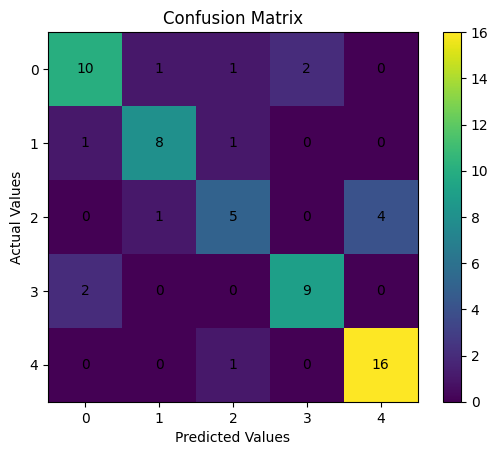

In [88]:
# Create a new figure for the plot
plt.figure()

# Display the confusion matrix as an image
plt.imshow(cm)

#Set title and label of axis
plt.title("Confusion Matrix")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

# Add a color scale bar to show intensity values
plt.colorbar()

# Add x-ticks and y-ticks marks
classes = np.unique(y_test)  # get unique class labels from test data
plt.xticks(classes)# set x-axis tick labels
plt.yticks(classes)# set y-axis tick labels

# Add numbers inside cells of plot
# Take each row of confusion matrix
for i in range(cm.shape[0]):
    # Take each column of confusion matrix
    for j in range(cm.shape[1]):
        # Display value inside each cell with center aligned
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()# dispaly plot

# Random Forest Accuracy, Classification Report and Confusion Matrix Insights:

The Random Forest model achieved an overall accuracy of 77.42%, indicating a good ability to classify images across the five categories. The classification report shows balanced performance, with precision and recall values mostly between 0.70 and 0.94. The model performed best on class 4, achieving a high recall of 0.94, meaning it correctly identified most instances of that class. However, performance for class 2 is weaker, with a recall of 0.50, indicating that many instances of this class were misclassified. The confusion matrix further confirms this, showing misclassification of class 2 samples into other classes, especially class 4. Overall, Random Forest handles most classes well but struggles slightly with classes that have overlapping visual features, which is common in image data.


# 4) Feature Importance Visualization:

In [89]:
importances = best_model.feature_importances_ #get feature importances

In [90]:
# Get indices of top 20 important features
top_n = 20
indices = np.argsort(importances)[-top_n:]
print('Top 20 important features:',indices)

Top 20 important features: [4676 3356 5057 6650 6794 4865 4337 4532 4148 4493 6791 4481 5117 6410
 4343 4310 4697 5246 4730 5285]


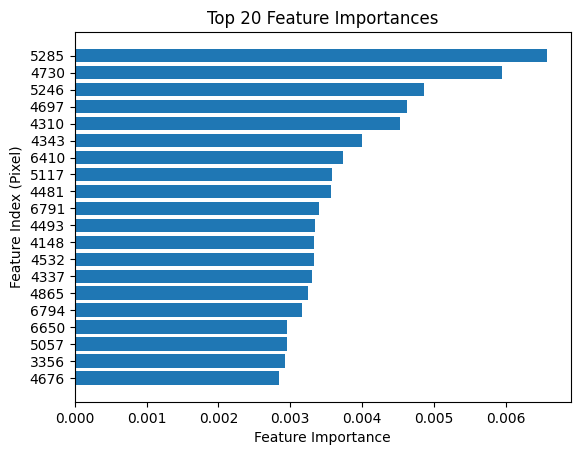

In [91]:
# Create a new figure for the plot
plt.figure()
# Create horizontal bar plot for feature importance
plt.barh(range(top_n), importances[indices])
# Add title, label of axis and yticks for top 20 pixel positions
plt.title("Top 20 Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature Index (Pixel)")
plt.yticks(range(top_n), indices)
plt.show()#display plot

# Top 20 Feature Importances Insights:

The feature importance plot shows the most significant pixels used by the model for classification. These pixels represent regions in the image that contain important visual information like edges and textures. However, since images are flattened, spatial relationships are lost, making interpretation less intuitive.


# 5) Prediction on New Images:

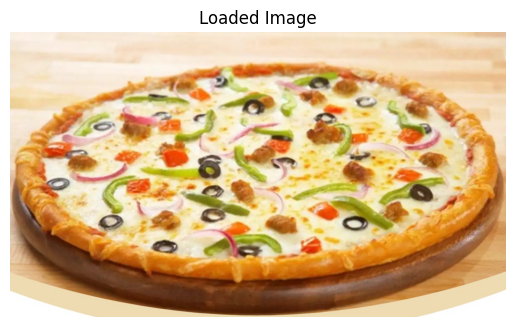

Class labels: ['dalmatian' 'dollar_bill' 'pizza' 'soccer_ball' 'sunflower']
Predicted Class: pizza


In [92]:
#Create function to predict the class of a new image
def predict_image(image_path, img_size=64):
    #Handle exception related to reading image
    try:
        img = cv2.imread(image_path)#read image
        #check image is None or not
        if img is None:
            raise ValueError("Image not loaded properly")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)#convert image BGR to RGB

        #Show loaded image
        plt.figure()#create new figure
        plt.imshow(img)#create image
        plt.title("Loaded Image")#add title
        plt.axis('off')#all axis off
        plt.show()#display image

        img = cv2.resize(img, (64, 64))#Resize image with 64X64 pixels
        img = img.astype('float32') / 255.0 #normalize image pixels from 0-255 to 0-1, to improve model stability
        img = img.reshape(1,-1)#convert image into 1D

        # Predict using best_model
        prediction = best_model.predict(img)
        print("Class labels:", le.classes_)

        # Convert numeric label back to original class
        predicted_class = le.inverse_transform(prediction)

        return predicted_class[0]  #display 1st class

    except Exception as e:

        print(f"Error processing {image_path}: {e}") #display error message
        return None

#Test function
test_image_path = "sample_data/test_image.jpg"  # new image path

result = predict_image(test_image_path)#call function with new image path

print("Predicted Class:", result)#display class result

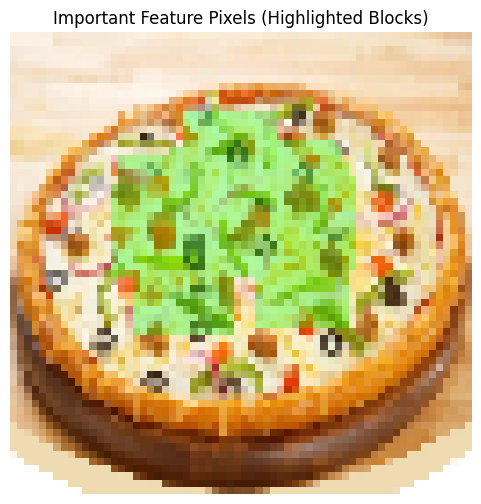

In [93]:
#Display important features on predicted image

# Function used to convert feature indices into (row, col) pixel positions
def get_pixel_positions(indices, img_size=64):
    positions = []#store position
    #take each index
    for idx in indices:
        pixel_index = idx // 3 #Each pixel has 3 values (R, G, B), so we divide by 3 to get actual pixel index

        # Convert 1D pixel index into 2D row position
        row = pixel_index // img_size

        # Convert 1D pixel index into column position
        col = pixel_index % img_size

        # Store pixel position
        positions.append((row, col))

    return positions #return position

#Function used to show important feature on image
def show_important_features(image_path, indices, block_size=6):
    # Load image from file
    img = cv2.imread(image_path)

    # Convert from BGR (OpenCV format) to RGB (for correct display in matplotlib)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize image to fixed size (64x64)
    img = cv2.resize(img, (64, 64))

    # Get pixel positions from feature indices
    positions = get_pixel_positions(indices)

    # Create a copy of image to draw overlays
    overlay = img.copy()
    #Take each row and column value from positions
    for (row, col) in positions:
        # Define top-left corner of square block
        top_left = (col - block_size, row - block_size)

        # Define bottom-right corner of square block
        bottom_right = (col + block_size, row + block_size)

        # Draw filled rectangle (important feature highlight)
        cv2.rectangle(overlay,top_left,bottom_right,
            (0, 255, 0),   # color of block (green in BGR format)
            -1             # -1 means filled rectangle
        )

    # Blend original image and overlay (to make highlight semi-transparent)
    output = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

    # Show final image
    plt.figure(figsize=(6,6))#Set figure size
    plt.imshow(output)#read iamge and show
    plt.title("Important Feature Pixels (Highlighted Blocks)")#add title
    plt.axis('off')#axis off
    plt.show()#display image

Top_20_indices=np.argsort(importances)[-top_n:]#take index of all top 20 important features
show_important_features("sample_data/test_image.jpg", Top_20_indices)#call function to see top 20 features on image

# Feature Importance Insights on New Image:

The green highlighted regions in image represent the pixels that the model has identified as most important for making its prediction. In this case, the model is mainly focusing on the central part of the pizza where the toppings are located, indicating that these visual features carry the most weight in classification. The outer crust and background areas are not highlighted, which suggests that they are considered less relevant by the model. Overall, this shows that the model is learning to prioritize meaningful visual patterns such as texture and toppings rather than irrelevant regions of the image.


# Task-6 Bonus: Comparing with SVM

SVM Accuracy: 0.7742

SVM Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.79      0.85        14
           1       0.75      0.90      0.82        10
           2       0.60      0.60      0.60        10
           3       0.73      0.73      0.73        11
           4       0.82      0.82      0.82        17

    accuracy                           0.77        62
   macro avg       0.76      0.77      0.76        62
weighted avg       0.78      0.77      0.77        62


SVM Confusion Matrix: [[11  0  0  3  0]
 [ 0  9  1  0  0]
 [ 0  1  6  0  3]
 [ 1  2  0  8  0]
 [ 0  0  3  0 14]]


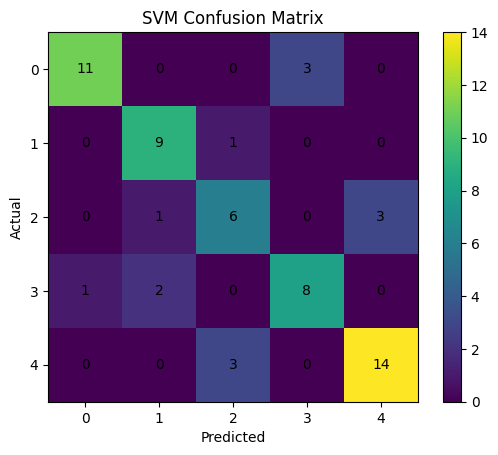

In [94]:
# Create SVM model with RBF kernel (non-linear decision boundary)
svc_model = SVC(kernel='rbf', random_state=42)
svc_model.fit(X_train, y_train)# Train model using training data
y_pred_svc = svc_model.predict(X_test)# Make predictions on test data

# Compute accuracy score of SVM model
print("SVM Accuracy:", round(accuracy_score(y_test, y_pred_svc),4))

# Find classification report which shows precision, recall, f1-score
print("\nSVM Classification Report:\n")
print(classification_report(y_test, y_pred_svc))
# Generate confusion matrix to evaluate prediction results
cm_svc = confusion_matrix(y_test, y_pred_svc)
print('\nSVM Confusion Matrix:',cm_svc)

# Create a new figure for plotting confusion matrix
plt.figure()
plt.imshow(cm_svc)# Display confusion matrix as a heatmap image
#Add title and label of axis
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add color bar to show intensity scale
plt.colorbar()

# Take each row of confusion matrix
for i in range(cm_svc.shape[0]):
    # Take each column of confusion matrix
    for j in range(cm_svc.shape[1]):
        # Display value inside each cell of matrix
        plt.text(j, i, cm_svc[i, j], ha='center', va='center')

plt.show()#display plot

# SVM Accuracy, Classification Report and Confusion Matrix Insights:

The SVM model also achieved an accuracy of 77.42%, matching the Random Forest model. However, its class-wise performance shows some differences. SVM demonstrates strong precision, especially for class 0 (0.92), meaning when it predicts this class, it is usually correct. It also shows improved recall for class 1 (0.90) compared to Random Forest, indicating better detection of that category. However, similar to Random Forest, SVM struggles with class 2, where both precision and recall are 0.60, suggesting difficulty in distinguishing this class from others. The confusion matrix shows misclassification mainly between visually similar categories. Overall, SVM provides slightly more balanced precision-recall trade-offs across classes but still faces challenges with complex image patterns.

In [95]:
#Compare the results of Random Forest and SVM models
rf_acc = accuracy_score(y_test, y_pred)#compute accuracy score of random forest model
svc_acc = accuracy_score(y_test, y_pred_svc)#compute accuracy score of SVC model

print("===== MODEL COMPARISON =====")
#Display accuracy score result of both model
print("Random Forest Accuracy:", round(rf_acc,4))
print("SVM Accuracy:", round(svc_acc,4))

#check both model accuracy
if rf_acc > svc_acc:
    print("Random Forest performs better")
elif svc_acc > rf_acc:
    print("SVM performs better")
else:
    print("Both models perform equally")

===== MODEL COMPARISON =====
Random Forest Accuracy: 0.7742
SVM Accuracy: 0.7742
Both models perform equally


# Model Comparison Based on All Results:

Both Random Forest and SVM models achieved the same overall accuracy (77.42%), indicating comparable performance on this dataset. However, their behavior differs at the class level. Random Forest performs better in identifying certain classes (like class 4 with high recall), while SVM provides slightly better precision and more consistent performance across multiple classes. Random Forest is generally more robust to noise and works well with high-dimensional data like images, while SVM is effective at finding optimal decision boundaries but can struggle with complex and overlapping patterns. Since both models perform equally in terms of accuracy, the choice between them depends on the specific requirement: Random Forest is preferable for robustness and interpretability, while SVM is suitable for achieving balanced classification performance.